# 09 — Fully nested ordinal ensemble

The authoritative algorithm lives in `src/experiment.py`. This notebook uses the same command-line workflow, not a separately implemented model. It evaluates generic inner-only hyperparameter selection, training-only early stopping, and QWK calibration on untouched outer folds. Historical best Optuna parameters are not imported.

Primary policy: **equal-weight CatBoost + XGBoost + ExtraTrees + Ridge**, followed by inner-OOF thresholds. The deployed model repeats that exact algorithm on all labeled training rows. A weighted ensemble remains a secondary comparison, never a silent replacement.

Project design followed earlier exploratory work on this dataset; resampling estimates are not a newly collected untouched cohort. Bootstrap intervals are conditional fixed-prediction diagnostics. No stable gain or clinical suitability is assumed.

In [1]:
import json
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

_ROOT = Path.cwd()
if _ROOT.name == "notebooks":
    _ROOT = _ROOT.parent
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))

from src.config import RESULTS_DIR, TARGET
from src.experiment import CANDIDATES, PRIMARY, ExperimentConfig, prepare_data, results_match, run_experiment
from src.verify import verify_artifacts

config = ExperimentConfig()
FORCE_RETRAIN = False
print("Reference configuration:", config)

Reference configuration: ExperimentConfig(outer_seeds=(42, 2026), outer_splits=5, inner_splits=3, threads=4, bootstrap_samples=2000, stopping_rounds=60, weight_resolution=4)


## 1. Row-local preparation and labeled-cohort audit

Read raw CSVs and regenerate Layer A. The experiment never trusts a stale precomputed parquet. All measurement-missing flags exclude season metadata; they make no claim about assessment administration. Median is the actual preprocessing function default. Learned statistics remain training-partition-only.

In [2]:
data = prepare_data()
print("Raw/labeled/unlabeled/test counts:",
      data["provenance"]["raw_train_rows"], len(data["y"]),
      data["provenance"]["unlabeled_rows"], len(data["X_test"]))
print("Feature count:", len(data["feature_columns"]))
print("Class counts:", data["provenance"]["class_counts"])
print("Cleaning audit:", data["provenance"]["cleaning"])

Raw/labeled/unlabeled/test counts: 3960 2736 1224 20
Feature count: 65
Class counts: {'0': 1594, '1': 730, '2': 378, '3': 34}
Cleaning audit: {'codebook': {}, 'domain': {'Physical-BMI': 7, 'Physical-Weight': 61, 'Physical-Diastolic_BP': 3, 'Physical-Systolic_BP': 1, 'CGAS-CGAS_Score': 1}, 'bmi': {'flagged': 0, 'nulled': 0}}


## 2. Explicit candidate grids and controlled baseline

Candidate 0 defines the untuned reference for each member. Three candidates per member tune capacity/regularization by inner-OOF RMSE. Ridge can use training-fold percentile clipping to control extreme input values. Every candidate is fit only inside the available training partition. The primary comparison is against the same equal ensemble without this adaptive selection.

In [3]:
print(json.dumps(CANDIDATES, indent=2))

{
  "catboost": [
    {
      "iterations": 600,
      "depth": 6,
      "learning_rate": 0.03,
      "l2_leaf_reg": 3.0
    },
    {
      "iterations": 900,
      "depth": 4,
      "learning_rate": 0.03,
      "l2_leaf_reg": 10.0,
      "bagging_temperature": 1.0
    },
    {
      "iterations": 1200,
      "depth": 5,
      "learning_rate": 0.02,
      "l2_leaf_reg": 20.0,
      "bagging_temperature": 1.0
    }
  ],
  "xgboost": [
    {
      "n_estimators": 1200,
      "max_depth": 6,
      "learning_rate": 0.03,
      "min_child_weight": 1,
      "reg_lambda": 1.0
    },
    {
      "n_estimators": 1200,
      "max_depth": 3,
      "learning_rate": 0.03,
      "min_child_weight": 5,
      "reg_lambda": 10.0,
      "subsample": 0.85,
      "colsample_bytree": 0.8,
      "reg_alpha": 0.1
    },
    {
      "n_estimators": 1600,
      "max_depth": 4,
      "learning_rate": 0.02,
      "min_child_weight": 10,
      "reg_lambda": 20.0,
      "subsample": 0.8,
      "colsample_bytree": 

## 3. Two-repeat fully nested experiment

Two seeds × five outer folds × three inner folds. Hyperparameters, stopping tree counts, thresholds, and secondary blend weights are selected without outer validation labels. The primary remains equal-weight by design.

An existing run is accepted only if data hashes, code hashes, package versions, configuration, and aggregate artifact hashes match. Set `FORCE_RETRAIN = True` to retrain even a verified matching run. If results are absent or stale, running all cells reproduces training.

In [4]:
metadata_path = RESULTS_DIR / "nested_metadata.json"
metadata = json.loads(metadata_path.read_text()) if metadata_path.exists() else {}
if not FORCE_RETRAIN and results_match(config, data, metadata):
    summary = pd.read_csv(RESULTS_DIR / "nested_cv_results.csv")
    print("Loaded matching reference run after data/code/environment/config/artifact checks.")
else:
    summary, metadata = run_experiment(config)
verified_metadata = verify_artifacts()
display(summary.sort_values("mean_oof_qwk", ascending=False).round(4))

Loaded matching reference run after data/code/environment/config/artifact checks.


Verified 14 models x 2 repeats: raw-data labels, all folds/QWK/class metrics, provenance, and reloaded deployment submission


,setup,mean_oof_qwk,ci_low,ci_high,repeat_std_qwk,repeats
0,Tuned equal ensemble,0.4669,0.4340,0.4973,0.0059,2
1,Tuned weighted ensemble,0.4627,0.4293,0.4926,0.0070,2
2,Tuned xgboost,0.4601,0.4270,0.4904,0.0007,2
3,Inner-selected single model,0.4579,0.4255,0.4890,0.0080,2
4,Baseline equal ensemble,0.4562,0.4219,0.4873,0.0025,2
5,Tuned extra_trees,0.4555,0.4208,0.4880,0.0015,2
6,Tuned catboost,0.4553,0.4226,0.4852,0.0081,2
7,Baseline catboost,0.4544,0.4208,0.4840,0.0064,2
8,Baseline extra_trees,0.4504,0.4173,0.4825,0.0036,2
9,Tuned ridge,0.4382,0.4045,0.4698,0.0024,2


## 4. Paired uncertainty and rare-class errors

The same participant indices are bootstrapped across repeats and comparators; repeated predictions are not independent children. These are fixed-prediction CIs, not complete retraining or post-selection intervals. A CI containing zero does not establish a reliable gain.

In [5]:
deltas = pd.read_csv(RESULTS_DIR / "nested_paired_deltas.csv")
display(deltas.round(4))
for row in deltas.itertuples():
    if not row.interval_excludes_zero:
        print(f"{row.reference}: interval includes zero; do not claim a reliable improvement.")

class_metrics = pd.read_csv(RESULTS_DIR / "nested_class_metrics.csv")
primary_classes = class_metrics.loc[class_metrics.setup.eq(PRIMARY)]
display(primary_classes.groupby("class")[["precision", "recall", "f1-score", "support", "true_positives"]].mean().round(3))
print("Class metrics average repeats; true-positive means can be fractional.")
print("The model is not a clinical screening or diagnostic system.")

,primary,reference,delta_qwk,ci_low,ci_high,interval_excludes_zero
0,Tuned equal ensemble,Inner-selected single model,0.0091,-0.0031,0.0213,False
1,Tuned equal ensemble,Baseline equal ensemble,0.0107,-0.0009,0.0227,False
2,Tuned equal ensemble,Tuned xgboost,0.0068,-0.0061,0.0202,False


Inner-selected single model: interval includes zero; do not claim a reliable improvement.
Baseline equal ensemble: interval includes zero; do not claim a reliable improvement.
Tuned xgboost: interval includes zero; do not claim a reliable improvement.


,precision,recall,f1-score,support,true_positives
class,,,,,
0,0.766,0.689,0.725,1594.0,1098.0
1,0.355,0.386,0.370,730.0,282.0
2,0.340,0.433,0.381,378.0,163.5
3,0.269,0.206,0.233,34.0,7.0


Class metrics average repeats; true-positive means can be fractional.
The model is not a clinical screening or diagnostic system.


## 5. Verify the exact exported policy

Submission IDs follow the sample-submission order. The persisted bundle contains the four selected member models, row-local feature contract, equal weights, and training-only calibrated thresholds. Reloaded predictions are checked independently against the saved submission.

In [6]:
deployment = verified_metadata["deployment"]
print("Exported policy:", deployment["policy"])
print("Weights:", deployment["weights"])
print("Thresholds:", deployment["thresholds"])
print("Selected candidates:", {name: record["candidate"] for name, record in deployment["selection"].items()})
print("Serialization round trip:", deployment["serialization_round_trip_verified"])
submission = pd.read_csv(RESULTS_DIR / "submission_nested.csv")
print("Example test prediction counts:", submission[TARGET].value_counts().sort_index().to_dict())
print("The public example test has no hidden-test/leaderboard evaluation score.")

Exported policy: Tuned equal ensemble
Weights: [0.25, 0.25, 0.25, 0.25]
Thresholds: [0.5329648629538986, 0.9126303357199944, 1.360815972239709]
Selected candidates: {'catboost': 2, 'xgboost': 2, 'extra_trees': 2, 'ridge': 2}
Serialization round trip: True
Example test prediction counts: {0: 6, 1: 14}
The public example test has no hidden-test/leaderboard evaluation score.


## 6. Generate the required technical report and anonymous archive

The seven-section `project.pdf` is generated from verified current results, with sources and limitations. The source archive contains sanitized notebooks, code, dependencies, aggregate results, and the report, excluding data, credentials, model binaries, Git history, and personal runtime paths. Perform a final human inspection before manual Moodle upload.

Verified 14 models x 2 repeats: raw-data labels, all folds/QWK/class metrics, provenance, and reloaded deployment submission


Generated project.pdf and docs/project.rendered.md from verified results


Verified 14 models x 2 repeats: raw-data labels, all folds/QWK/class metrics, provenance, and reloaded deployment submission
Built dist/project.zip: 46 allowlisted files; source/notebook anonymity patterns and manifest verified


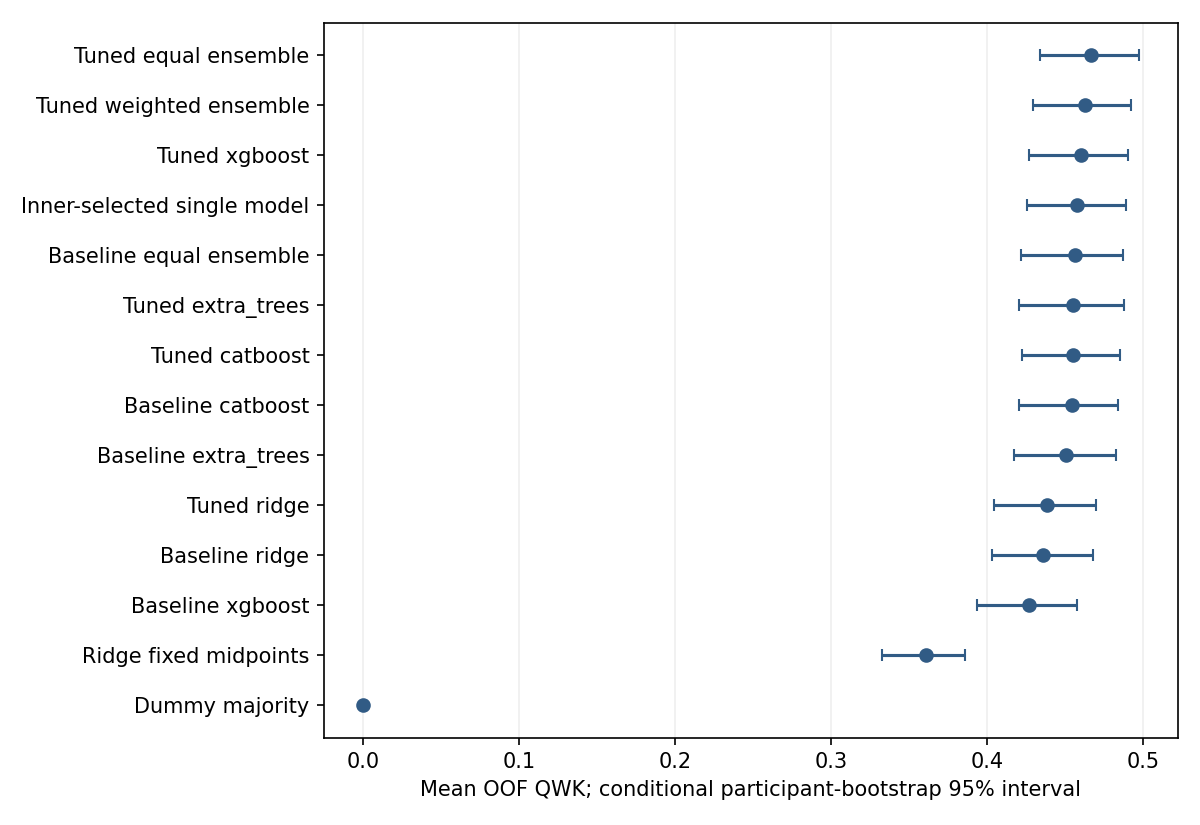

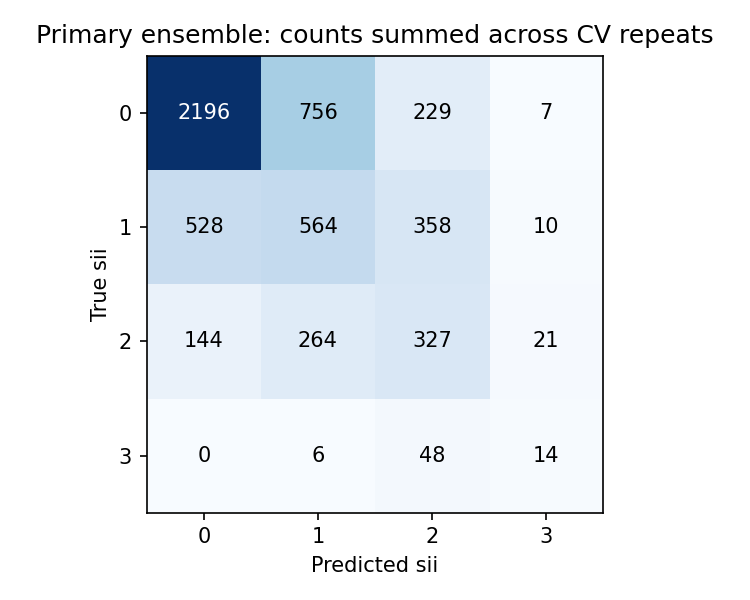

In [7]:
from src.report import build_report
from src.package import build_archive

build_report()
build_archive()
display(Image(filename=str(RESULTS_DIR / "figures" / "nested_qwk.png")))
display(Image(filename=str(RESULTS_DIR / "figures" / "nested_confusion.png")))